In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, f1_score, precision_score, recall_score, roc_auc_score, confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.utils import all_estimators # Added this import
import warnings
warnings.filterwarnings('ignore')

In [3]:
from google.colab import files
uploaded = files.upload()

Saving medical-charges.csv to medical-charges.csv


In [4]:
# Load the dataset
df = pd.read_csv("medical-charges.csv")

# EDA

In [5]:
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [6]:
print("Shape:", df.shape)
print(df.head())
print("\nData types:\n", df.dtypes)
print("\nMissing values:\n", df.isnull().sum())
print("\nDescriptive stats:\n", df.describe())

Shape: (1338, 7)
   age     sex     bmi  children smoker     region      charges
0   19  female  27.900         0    yes  southwest  16884.92400
1   18    male  33.770         1     no  southeast   1725.55230
2   28    male  33.000         3     no  southeast   4449.46200
3   33    male  22.705         0     no  northwest  21984.47061
4   32    male  28.880         0     no  northwest   3866.85520

Data types:
 age           int64
sex          object
bmi         float64
children      int64
smoker       object
region       object
charges     float64
dtype: object

Missing values:
 age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

Descriptive stats:
                age          bmi     children       charges
count  1338.000000  1338.000000  1338.000000   1338.000000
mean     39.207025    30.663397     1.094918  13270.422265
std      14.049960     6.098187     1.205493  12110.011237
min      18.000000    15.960000     0.000000 

In [7]:
import os

X = df.drop(columns=['charges'])
y = df['charges']

OUTPUT_DIR = "output"
os.makedirs(OUTPUT_DIR, exist_ok=True)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.to_csv(f"{OUTPUT_DIR}/X_train.csv", index=False)
X_test.to_csv(f"{OUTPUT_DIR}/X_test.csv", index=False)
y_train.to_csv(f"{OUTPUT_DIR}/y_train.csv", index=False)
y_test.to_csv(f"{OUTPUT_DIR}/y_test.csv", index=False)
print("Data split into training and testing sets. Shapes:")
print(f"X_train: {X_train.shape}")
print(f"X_test: {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test: {y_test.shape}")

Data split into training and testing sets. Shapes:
X_train: (1070, 6)
X_test: (268, 6)
y_train: (1070,)
y_test: (268,)


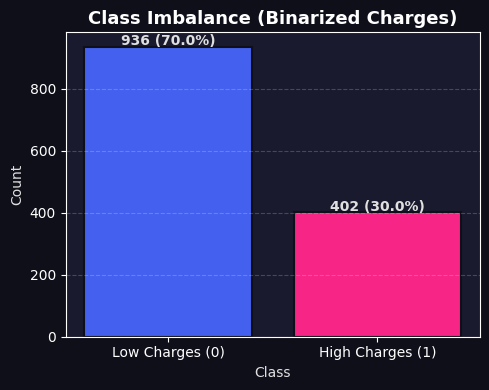

In [8]:
# Define color variables for the dark theme
PALETTE = ['#4361ee','#f72585','#7209b7','#3a0ca3','#4cc9f0','#560bad','#480ca8']
BG, CARD, TEXT = '#0f0f1a', '#1a1a2e', '#e0e0e0'
ACCENT, PINK, CYAN = '#4361ee', '#f72585', '#4cc9f0'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': '#333355', 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#222244',
    'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
})

threshold = df['charges'].quantile(0.70)
binary_charges = (df['charges'] >= threshold).astype(int)

counts = binary_charges.value_counts().sort_index()
labels = ['Low Charges (0)', 'High Charges (1)']

plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(5, 4), facecolor=BG)
ax.set_facecolor(CARD)

bars = ax.bar(
    labels,
    counts.values,
    color=[ACCENT, PINK],
    edgecolor=BG,
    linewidth=1.5
)

# Add value + percentage
total = counts.sum()
for i, v in enumerate(counts.values):
    pct = (v / total) * 100
    ax.text(i, v + 5, f"{v} ({pct:.1f}%)",
            ha='center', fontsize=10, fontweight='bold', color=TEXT)

# Titles & labels
ax.set_title('Class Imbalance (Binarized Charges)',
             fontsize=13, fontweight='bold', color='white')
ax.set_ylabel('Count', color=TEXT)
ax.set_xlabel('Class', color=TEXT)

# Grid style
ax.grid(axis='y', linestyle='--', alpha=0.2)

plt.tight_layout()
plt.show()

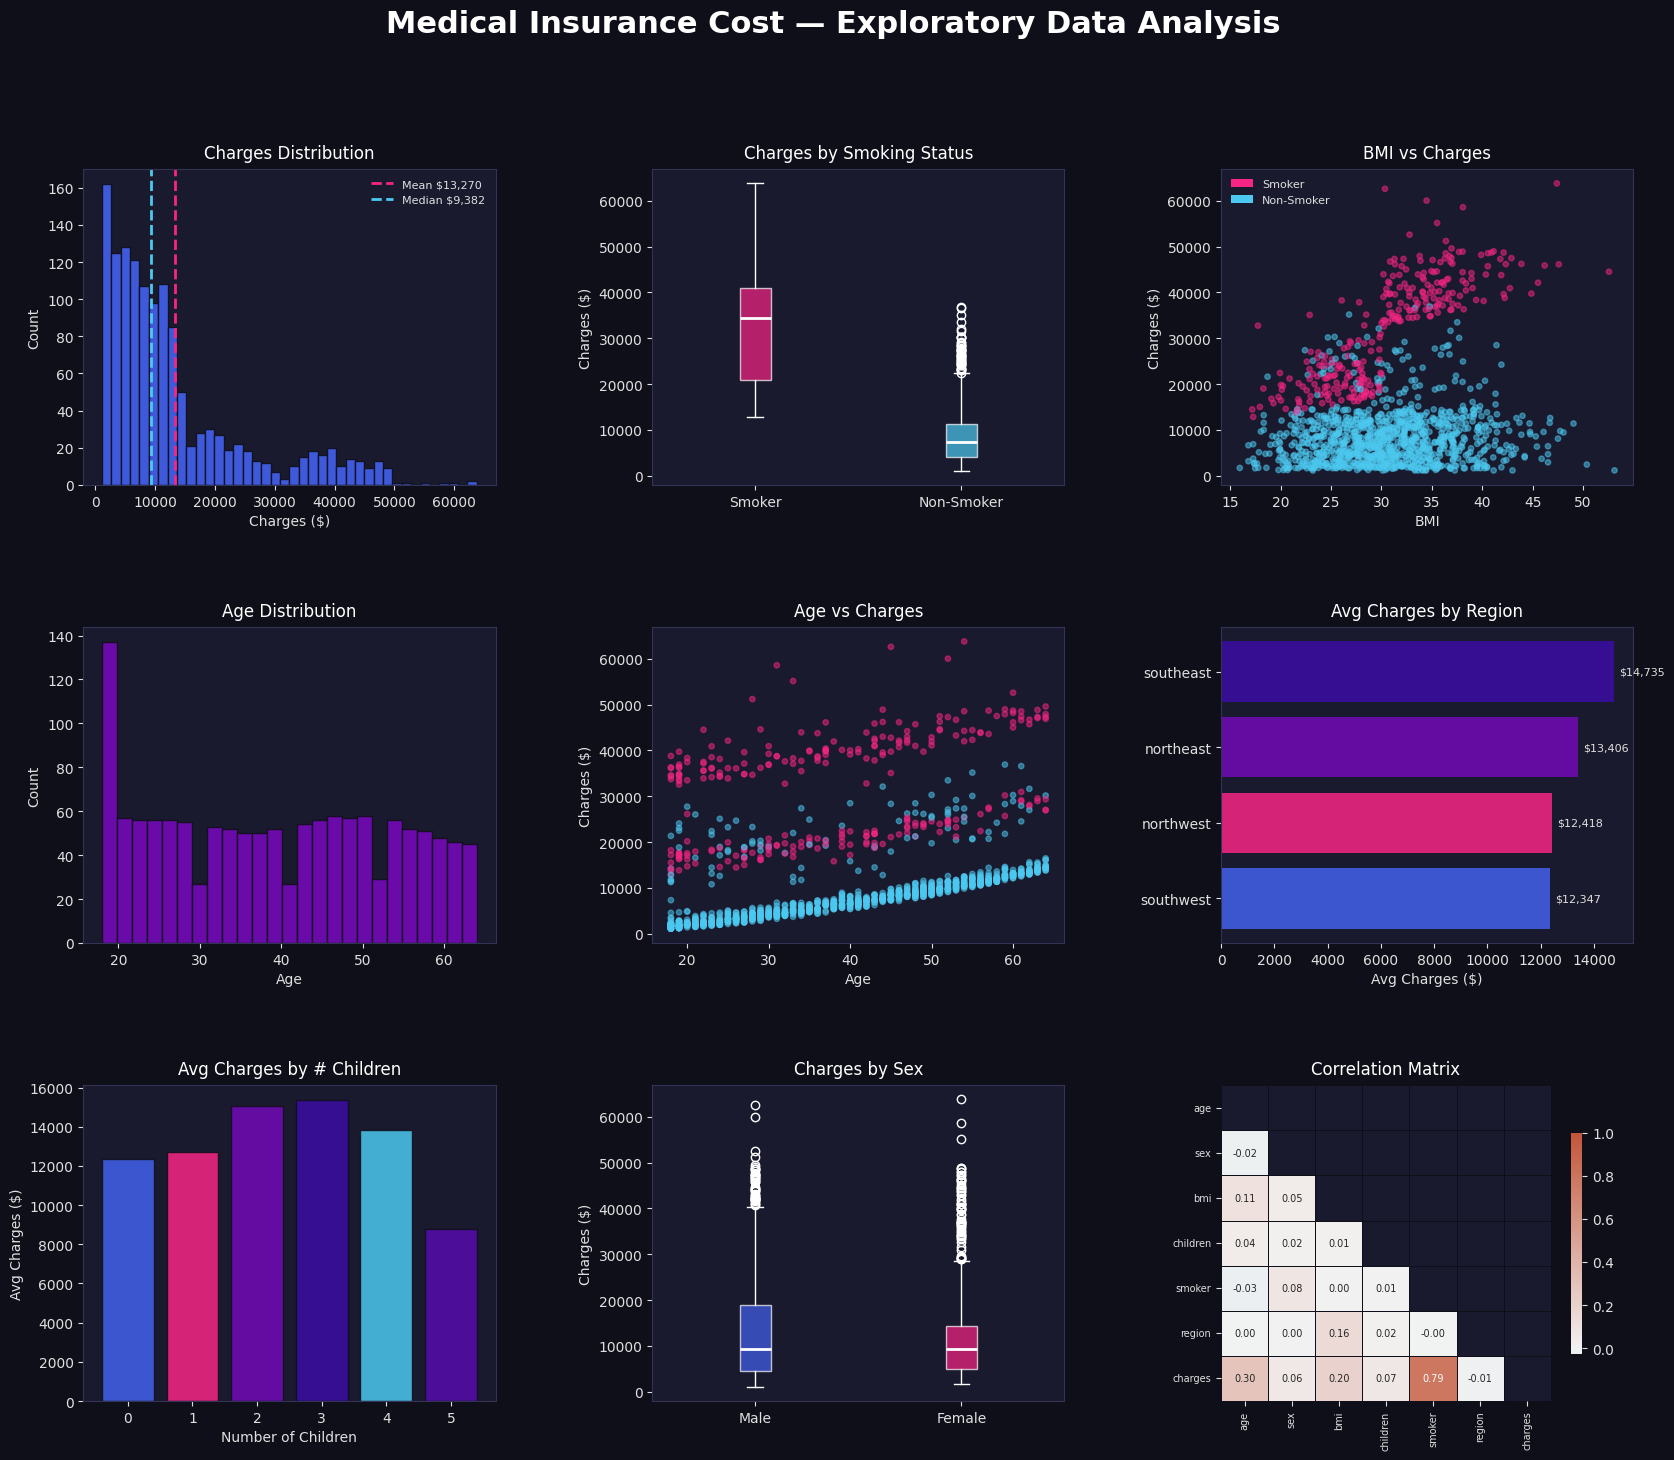

In [9]:
plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': '#333355', 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#222244',
    'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
})

fig = plt.figure(figsize=(20, 16), facecolor=BG)
fig.suptitle('Medical Insurance Cost — Exploratory Data Analysis',
             fontsize=22, color='white', fontweight='bold', y=0.98)
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.45, wspace=0.38)

# Charges distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.hist(df['charges'], bins=40, color=ACCENT, edgecolor=BG, alpha=0.9)
ax1.set_title('Charges Distribution', color='white', fontsize=12, pad=8)
ax1.set_xlabel('Charges ($)'); ax1.set_ylabel('Count')
ax1.axvline(df['charges'].mean(), color=PINK, lw=2, linestyle='--', label=f"Mean ${df['charges'].mean():,.0f}")
ax1.axvline(df['charges'].median(), color=CYAN, lw=2, linestyle='--', label=f"Median ${df['charges'].median():,.0f}")
ax1.legend(fontsize=8, facecolor=CARD, edgecolor='none')

# Charges by smoker
ax2 = fig.add_subplot(gs[0, 1])
bp = ax2.boxplot([df[df['smoker']=='yes']['charges'], df[df['smoker']=='no']['charges']],
                 patch_artist=True, labels=['Smoker', 'Non-Smoker'],
                 medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp['boxes'], [PINK, CYAN]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax2.set_title('Charges by Smoking Status', color='white', fontsize=12, pad=8)
ax2.set_ylabel('Charges ($)')

# BMI vs Charges
ax3 = fig.add_subplot(gs[0, 2])
colors = [PINK if s == 'yes' else CYAN for s in df['smoker']]
ax3.scatter(df['bmi'], df['charges'], c=colors, alpha=0.5, s=15)
ax3.set_title('BMI vs Charges', color='white', fontsize=12, pad=8)
ax3.set_xlabel('BMI'); ax3.set_ylabel('Charges ($)')
from matplotlib.patches import Patch
ax3.legend(handles=[Patch(facecolor=PINK, label='Smoker'), Patch(facecolor=CYAN, label='Non-Smoker')],
           facecolor=CARD, edgecolor='none', fontsize=8)

# Age distribution
ax4 = fig.add_subplot(gs[1, 0])
ax4.hist(df['age'], bins=25, color='#7209b7', edgecolor=BG, alpha=0.9)
ax4.set_title('Age Distribution', color='white', fontsize=12, pad=8)
ax4.set_xlabel('Age'); ax4.set_ylabel('Count')

# Age vs Charges
ax5 = fig.add_subplot(gs[1, 1])
ax5.scatter(df['age'], df['charges'], c=colors, alpha=0.5, s=15)
ax5.set_title('Age vs Charges', color='white', fontsize=12, pad=8)
ax5.set_xlabel('Age'); ax5.set_ylabel('Charges ($)')

# Avg charges by region
ax6 = fig.add_subplot(gs[1, 2])
region_means = df.groupby('region')['charges'].mean().sort_values()
bars = ax6.barh(region_means.index, region_means.values, color=PALETTE[:4], alpha=0.85)
ax6.set_title('Avg Charges by Region', color='white', fontsize=12, pad=8)
ax6.set_xlabel('Avg Charges ($)')
for bar, val in zip(bars, region_means.values):
    ax6.text(val + 200, bar.get_y() + bar.get_height()/2, f'${val:,.0f}', va='center', fontsize=8)

# Avg charges by children
ax7 = fig.add_subplot(gs[2, 0])
child_means = df.groupby('children')['charges'].mean()
ax7.bar(child_means.index, child_means.values, color=PALETTE, alpha=0.85, edgecolor=BG)
ax7.set_title('Avg Charges by # Children', color='white', fontsize=12, pad=8)
ax7.set_xlabel('Number of Children'); ax7.set_ylabel('Avg Charges ($)')

# Charges by sex
ax8 = fig.add_subplot(gs[2, 1])
bp2 = ax8.boxplot([df[df['sex']=='male']['charges'], df[df['sex']=='female']['charges']],
                  patch_artist=True, labels=['Male', 'Female'],
                  medianprops=dict(color='white', linewidth=2))
for patch, color in zip(bp2['boxes'], [ACCENT, PINK]):
    patch.set_facecolor(color); patch.set_alpha(0.7)
ax8.set_title('Charges by Sex', color='white', fontsize=12, pad=8)
ax8.set_ylabel('Charges ($)')

# Correlation heatmap
ax9 = fig.add_subplot(gs[2, 2])
df_enc = df.copy()
for col in ['sex', 'smoker', 'region']:
    df_enc[col] = LabelEncoder().fit_transform(df_enc[col])
corr = df_enc.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap=sns.diverging_palette(230, 20, as_cmap=True),
            vmax=1, center=0, ax=ax9, annot=True, fmt='.2f',
            annot_kws={'size': 7}, linewidths=0.5, linecolor='#0f0f1a',
            cbar_kws={'shrink': 0.7})
ax9.set_title('Correlation Matrix', color='white', fontsize=12, pad=8)
ax9.set_xticklabels(ax9.get_xticklabels(), fontsize=7)
ax9.set_yticklabels(ax9.get_yticklabels(), fontsize=7)

plt.savefig('eda.png', dpi=150, bbox_inches='tight', facecolor=BG)
plt.show()
plt.close()

1. The dominant factor is Smoking Status. The Charges by Smoking Status box plot and the Correlation Matrix reveal that smoking is the most significant predictor of medical costs. There is a massive gap between the median charges for smokers (around 35k) versus non-smokers (under 10k). This suggests that building any predictive model should treat smoking status as a primary feature.

2. The relationship between BMI and charges depends on smoking status. For non-smokers, charges stay low and do not change much even if BMI increases. However, for smokers, charges increase quickly as BMI goes up. When BMI is above 30, the costs rise sharply and can go over 40k.

3. In the Age vs Charges plot, there is a clear upward linear trend across all groups. As people get older, their medical costs increase. The plot shows three groups: low-risk (mostly non-smokers), medium-risk, and high-risk (usually smokers with high BMI). In all groups, costs go up steadily with age.

4. Regional and demographic factors show some variation in medical costs, although their impact is not as strong as other variables. From the regional analysis, the Southeast has the highest average charges, which may be influenced by a higher number of smokers or individuals with higher BMI in that group. When looking at the number of children, medical costs tend to increase for families with two or three children, but then decrease for those with five children. This drop is most likely caused by a smaller sample size rather than indicating that larger families actually have lower costs. In terms of sex, the median charges between males and females are quite similar, but males tend to have more extreme high-cost outliers and a slightly wider spread of expensive cases.

5. The Charges Distribution histogram shows that it is right skewed. This means most people have low costs, but a small number have very high costs. Because of this, the average is higher than the median. To improve a machine learning model, it is better to apply a log transformation to the charges.

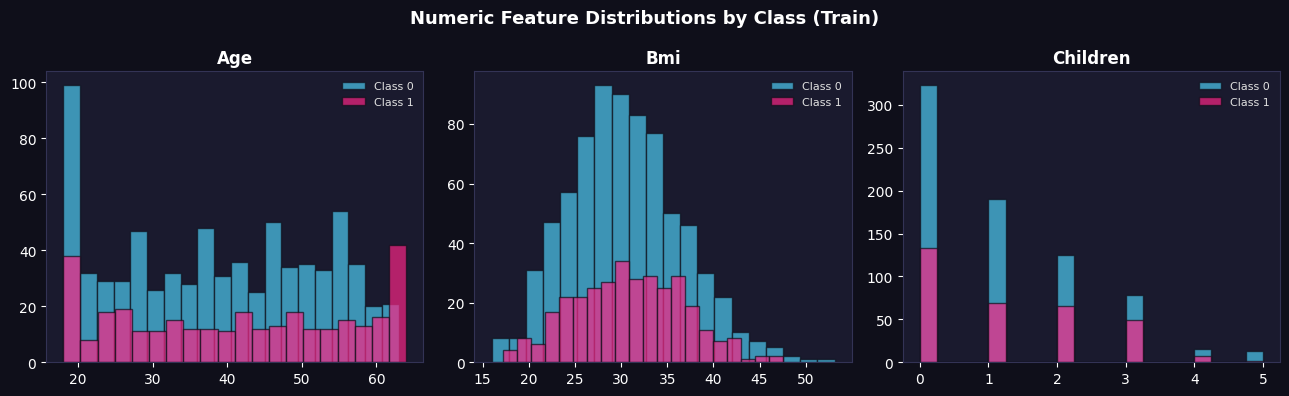

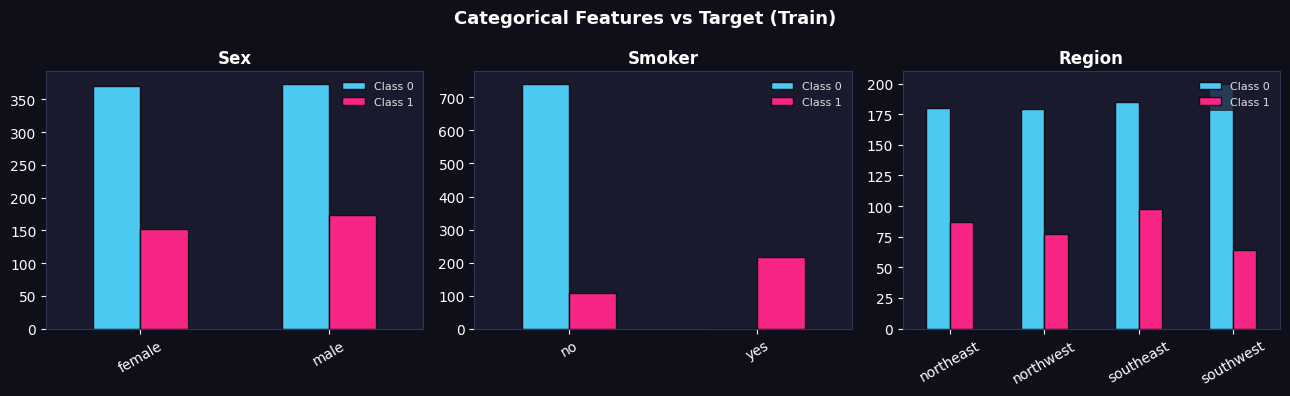

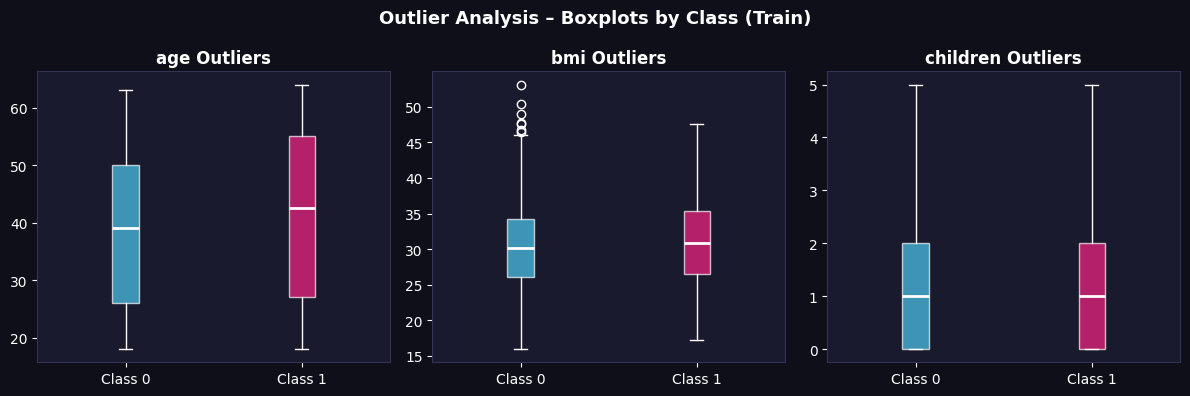

In [10]:
df_train = X_train.copy()
df_train['target'] = (y_train >= threshold).astype(int)

df_test = X_test.copy()
df_test['target'] = (y_test >= threshold).astype(int)

PALETTE = ['#4361ee','#f72585','#7209b7','#3a0ca3','#4cc9f0','#560bad','#480ca8']
BG, CARD, TEXT = '#0f0f1a', '#1a1a2e', '#e0e0e0'
ACCENT, PINK, CYAN = '#4361ee', '#f72585', '#4cc9f0'

plt.rcParams.update({
    'figure.facecolor': BG, 'axes.facecolor': CARD,
    'axes.edgecolor': '#333355', 'axes.labelcolor': TEXT,
    'xtick.color': TEXT, 'ytick.color': TEXT,
    'text.color': TEXT, 'grid.color': '#222244',
    'grid.alpha': 0.5, 'font.family': 'DejaVu Sans',
})

# Numeric distributions
num_cols = ['age', 'bmi', 'children']
fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor=BG)

for i, col in enumerate(num_cols):
    axes[i].set_facecolor(CARD)

    for cls, color in [(0, CYAN), (1, PINK)]:
        axes[i].hist(
            df_train[df_train['target']==cls][col],
            bins=20,
            alpha=0.7,
            color=color,
            edgecolor=BG,
            label=f'Class {cls}'
        )

    axes[i].set_title(col.capitalize(), color='white', fontweight='bold')
    axes[i].tick_params(colors='white')
    axes[i].legend(facecolor=CARD, edgecolor='none', fontsize=8)

fig.suptitle('Numeric Feature Distributions by Class (Train)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()


# Categorical distributions
cat_cols = ['sex', 'smoker', 'region']
fig, axes = plt.subplots(1, 3, figsize=(13, 4), facecolor=BG)

for i, col in enumerate(cat_cols):
    axes[i].set_facecolor(CARD)

    ct = df_train.groupby([col, 'target']).size().unstack(fill_value=0)
    ct.plot(
        kind='bar',
        ax=axes[i],
        color=[CYAN, PINK],
        edgecolor=BG,
        linewidth=1
    )

    axes[i].set_title(col.capitalize(), color='white', fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].tick_params(axis='x', rotation=30, colors='white')
    axes[i].tick_params(axis='y', colors='white')
    axes[i].legend(['Class 0', 'Class 1'], facecolor=CARD, edgecolor='none', fontsize=8)

fig.suptitle('Categorical Features vs Target (Train)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()


# Outlier analysis
fig, axes = plt.subplots(1, 3, figsize=(12, 4), facecolor=BG)

for i, col in enumerate(num_cols):
    axes[i].set_facecolor(CARD)

    bp = axes[i].boxplot(
        [df_train[df_train['target']==0][col].dropna(),
         df_train[df_train['target']==1][col].dropna()],
        labels=['Class 0', 'Class 1'],
        patch_artist=True,
        medianprops=dict(color='white', linewidth=2)
    )

    for patch, color in zip(bp['boxes'], [CYAN, PINK]):
        patch.set_facecolor(color)
        patch.set_alpha(0.7)

    axes[i].set_title(f'{col} Outliers', color='white', fontweight='bold')
    axes[i].tick_params(colors='white')

fig.suptitle('Outlier Analysis – Boxplots by Class (Train)',
             fontsize=13, fontweight='bold', color='white')
plt.tight_layout()
plt.show()

# Preprocessing

In [11]:
# Categorical columns
cat_cols = X_train.select_dtypes(include=['object', 'category', 'bool']).columns
print("Categorical columns:", cat_cols)

# One-Hot Encoding
X_train_enc = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_enc = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

Categorical columns: Index(['sex', 'smoker', 'region'], dtype='object')


In [12]:
X_train_enc.head()

,age,bmi,children,sex_male,smoker_yes,region_northwest,region_southeast,region_southwest
560,46,19.95,2,False,False,True,False,False
1285,47,24.32,0,False,False,False,False,False
1142,52,24.86,0,False,False,False,True,False
969,39,34.32,5,False,False,False,True,False
486,54,21.47,3,False,False,True,False,False


In [13]:
from sklearn.preprocessing import StandardScaler

num_feats = ['age', 'bmi', 'children']
scaler = StandardScaler()
X_train_scaled = X_train_enc.copy()
X_test_scaled = X_test_enc.copy()

X_train_scaled[num_feats] = scaler.fit_transform(X_train_enc[num_feats])
X_test_scaled[num_feats] = scaler.transform(X_test_enc[num_feats])

print("Standardization complete.")
print(f"X_train_scaled shape: {X_train_scaled.shape}")
print(f"X_test_scaled shape: {X_test_scaled.shape}")

print("\nX_train_scaled head:")
print(X_train_scaled.head())
print("\nX_test_scaled head:")
print(X_test_scaled.head())

Standardization complete.
X_train_scaled shape: (1070, 8)
X_test_scaled shape: (268, 8)

X_train_scaled head:
           age       bmi  children  sex_male  smoker_yes  region_northwest  \
560   0.472227 -1.756525  0.734336     False       False              True   
1285  0.543313 -1.033082 -0.911192     False       False             False   
1142  0.898745 -0.943687 -0.911192     False       False             False   
969  -0.025379  0.622393  3.202629     False       False             False   
486   1.040918 -1.504893  1.557100     False       False              True   

      region_southeast  region_southwest  
560              False             False  
1285             False             False  
1142              True             False  
969               True             False  
486              False             False  

X_test_scaled head:
           age       bmi  children  sex_male  smoker_yes  region_northwest  \
764   0.401140 -0.891539  0.734336     False       False        


Feature scores (f_classif):
smoker_yes          1446.980175
age                   11.130819
region_southwest       6.437049
region_southeast       3.149033
children               1.860663
bmi                    1.679549
sex_male               0.873988
region_northwest       0.024013
dtype: float64

Selected 6 features: ['smoker_yes', 'age', 'region_southwest', 'region_southeast', 'children', 'bmi']


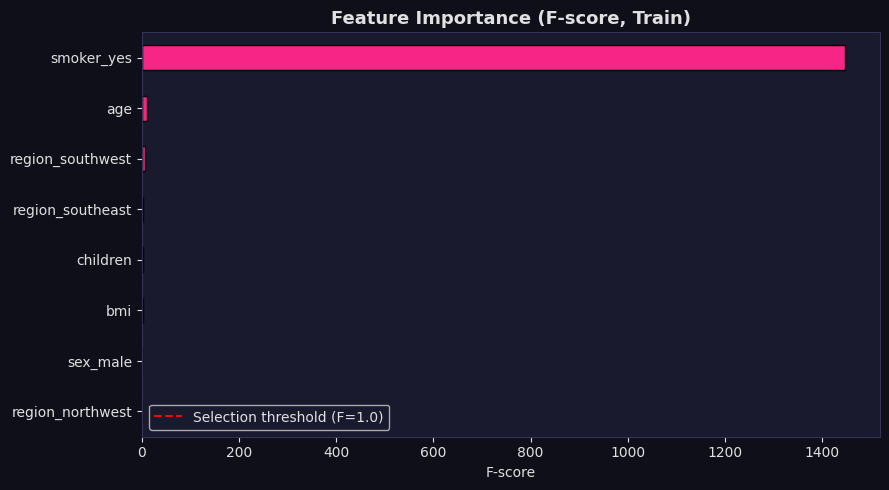

In [14]:
# Feature Selection: SelectKBest (f_classif), keep F-score > 1
from sklearn.feature_selection import SelectKBest, f_classif

selector = SelectKBest(score_func=f_classif, k='all')
selector.fit(X_train_scaled, df_train['target'])
feat_scores = pd.Series(selector.scores_, index=X_train_scaled.columns).sort_values(ascending=False)
print("\nFeature scores (f_classif):")
print(feat_scores)

top_feats = feat_scores[feat_scores > 1.0].index.tolist()
print(f"\nSelected {len(top_feats)} features: {top_feats}")

X_train_final = X_train_scaled[top_feats]
X_test_final  = X_test_scaled[top_feats]

# Feature importance plot
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 5))
feat_scores.sort_values().plot(kind='barh', ax=ax, color='#f72585', edgecolor='black')
ax.axvline(1.0, color='red', linestyle='--', label='Selection threshold (F=1.0)')
ax.set_title('Feature Importance (F-score, Train)', fontsize=13, fontweight='bold')
ax.set_xlabel('F-score')
ax.legend()
plt.tight_layout()
plt.show()

**Imbalance class handling**

In [15]:
from imblearn.under_sampling import TomekLinks
from imblearn.over_sampling import RandomOverSampler

# Apply Tomek Links
tomek = TomekLinks(sampling_strategy='auto')
X_clean, y_clean_target = tomek.fit_resample(X_train_final, df_train['target'])

print("After Tomek Links:")
print(X_clean.shape)
print(y_clean_target.value_counts())

# Apply Random Oversampling to the cleaned data
ros = RandomOverSampler(random_state=42)
X_train_res, y_train_res_target = ros.fit_resample(X_clean, y_clean_target)

print("\nAfter Random Oversampling:")
print(X_train_res.shape)
print(y_train_res_target.value_counts())

After Tomek Links:
(1020, 6)
target
0    694
1    326
Name: count, dtype: int64

After Random Oversampling:
(1388, 6)
target
0    694
1    694
Name: count, dtype: int64


**Modeling with LazyClassifiers**

In [16]:
SKIP = {'ClassifierChain', 'MultiOutputClassifier', 'OneVsOneClassifier',
        'OneVsRestClassifier', 'OutputCodeClassifier', 'VotingClassifier',
        'StackingClassifier', 'CalibratedClassifierCV', 'CheckingClassifier',
        'CategoricalNB'}

all_clfs = [(name, clf) for name, clf in all_estimators(type_filter='classifier')
            if name not in SKIP]

results = []
best_models = {}

print(f"\nRunning {len(all_clfs)} classifiers...")
for name, ClfClass in all_clfs:
    try:
        try:
            clf = ClfClass(random_state=42, class_weight='balanced')
        except TypeError:
            try:
                clf = ClfClass(random_state=42)
            except TypeError:
                clf = ClfClass()

        # Corrected: Use y_train_res_target instead of y_train_res
        clf.fit(X_train_res, y_train_res_target)
        y_pred = clf.predict(X_test_final)

        try:
            if hasattr(clf, 'predict_proba'):
                y_prob = clf.predict_proba(X_test_final)[:, 1]
            elif hasattr(clf, 'decision_function'):
                y_prob = clf.decision_function(X_test_final)
                y_prob = (y_prob - y_prob.min()) / (y_prob.max() - y_prob.min() + 1e-9)
            else:
                y_prob = y_pred.astype(float)
            auc = roc_auc_score(df_test['target'], y_prob) # Corrected y_test to df_test['target']
        except:
            auc = np.nan

        results.append({
            'Model': name,
            'Accuracy': accuracy_score(df_test['target'], y_pred), # Corrected y_test to df_test['target']
            'F1 (macro)': f1_score(df_test['target'], y_pred, average='macro'), # Corrected y_test to df_test['target']
            'Precision': precision_score(df_test['target'], y_pred, average='macro', zero_division=0), # Corrected y_test to df_test['target']
            'Recall': recall_score(df_test['target'], y_pred, average='macro'), # Corrected y_test to df_test['target']
            'ROC-AUC': auc,
        })
        best_models[name] = (clf, y_pred)
        print(f"  ✓ {name}")
    except Exception as e:
        print(f"  ✘ {name}: {str(e)[:60]}")

results_df = pd.DataFrame(results).sort_values('F1 (macro)', ascending=False).reset_index(drop=True)
print("\nTop 10 models:")
print(results_df.head(10).to_string())


Running 35 classifiers...
  ✓ AdaBoostClassifier
  ✓ BaggingClassifier
  ✓ BernoulliNB
  ✘ ComplementNB: Negative values in data passed to ComplementNB (input X).
  ✓ DecisionTreeClassifier
  ✓ DummyClassifier
  ✓ ExtraTreeClassifier
  ✓ ExtraTreesClassifier
  ✘ FixedThresholdClassifier: FixedThresholdClassifier.__init__() missing 1 required posit
  ✓ GaussianNB
  ✓ GaussianProcessClassifier
  ✓ GradientBoostingClassifier
  ✓ HistGradientBoostingClassifier
  ✓ KNeighborsClassifier
  ✓ LabelPropagation
  ✓ LabelSpreading
  ✓ LinearDiscriminantAnalysis
  ✓ LinearSVC
  ✓ LogisticRegression
  ✓ LogisticRegressionCV
  ✓ MLPClassifier
  ✘ MultinomialNB: Negative values in data passed to MultinomialNB (input X).
  ✓ NearestCentroid
  ✓ NuSVC
  ✓ PassiveAggressiveClassifier
  ✓ Perceptron
  ✓ QuadraticDiscriminantAnalysis
  ✘ RadiusNeighborsClassifier: No neighbors found for test samples array([ 66,  84, 212, 24
  ✓ RandomForestClassifier
  ✓ RidgeClassifier
  ✓ RidgeClassifierCV
  ✓ SGDClass

In [17]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import classification_report, roc_auc_score

gbc = GradientBoostingClassifier(random_state=42)

# Define the parameter grid for GridSearchCV
param_grid = {
    'n_estimators': [50, 100, 200], # Number of boosting stages
    'learning_rate': [0.01, 0.1, 0.2], # Step size shrinkage
    'max_depth': [3, 4, 5], # Maximum depth of the individual regression estimators
    'subsample': [0.7, 0.8, 0.9], # Fraction of samples to be used for fitting the individual base learners
    # 'min_samples_split': [2, 5], # Minimum number of samples required to split an internal node
    # 'min_samples_leaf': [1, 2], # Minimum number of samples required to be at a leaf node
}

# Initialize GridSearchCV
grid_search = GridSearchCV(
    estimator=gbc,
    param_grid=param_grid,
    cv=5, # 5-fold cross-validation
    scoring='roc_auc', # Optimize for ROC-AUC score
    n_jobs=-1, # Use all available CPU cores
    verbose=2 # Display progress
)

print("\nStarting GridSearchCV for GradientBoostingClassifier...")

# Fit GridSearchCV on the resampled training data
grid_search.fit(X_train_res, y_train_res_target)

print("\nGridSearchCV complete.")

# Get the best estimator
best_gbc = grid_search.best_estimator_

print(f"\nBest Hyperparameters: {grid_search.best_params_}")
print(f"Best ROC-AUC score on validation sets: {grid_search.best_score_:.4f}")

# Evaluate the best model on the test set
y_pred_gbc = best_gbc.predict(X_test_final)
y_prob_gbc = best_gbc.predict_proba(X_test_final)[:, 1]

roc_auc_gbc = roc_auc_score(df_test['target'], y_prob_gbc)

print("\nTest Set Evaluation for Tuned GradientBoostingClassifier:")
print(f"ROC-AUC: {roc_auc_gbc:.4f}")
print(classification_report(df_test['target'], y_pred_gbc, target_names=['Low Charges', 'High Charges']))



Starting GridSearchCV for GradientBoostingClassifier...
Fitting 5 folds for each of 81 candidates, totalling 405 fits

GridSearchCV complete.

Best Hyperparameters: {'learning_rate': 0.2, 'max_depth': 5, 'n_estimators': 100, 'subsample': 0.7}
Best ROC-AUC score on validation sets: 0.9801

Test Set Evaluation for Tuned GradientBoostingClassifier:
ROC-AUC: 0.9105
              precision    recall  f1-score   support

 Low Charges       0.93      0.96      0.95       192
High Charges       0.90      0.82      0.86        76

    accuracy                           0.92       268
   macro avg       0.91      0.89      0.90       268
weighted avg       0.92      0.92      0.92       268



The model performs very well, especially for 'Low Charges' with high precision and recall (0.93 precision, 0.96 recall). For 'High Charges', the performance is also good (0.90 precision, 0.82 recall), indicating that the model is quite effective at identifying both classes of medical charges.